# Notebook 02 — Régression Linéaire

## Théorie : Régression Linéaire

### Formule générale
$$\hat{y} = X\mathbf{w} + b$$

Où :
- $X$ : matrice des features (n_samples × n_features)
- $\mathbf{w}$ : vecteur des coefficients appris
- $b$ : biais (intercept)
- $\hat{y}$ : prédiction

### Optimisation
Les poids $\mathbf{w}$ sont estimés par la **méthode des moindres carrés ordinaires** (OLS) :
$$\mathbf{w} = (X^T X)^{-1} X^T y$$

### Hypothèses du modèle
1. **Linéarité** : relation linéaire entre les features et la cible
2. **Homoscédasticité** : variance constante des résidus
3. **Indépendance** des observations
4. **Normalité** des résidus

### Limites
- Ne capture pas les relations non-linéaires
- Sensible aux outliers
- Suppose l'indépendance entre features (multicolinéarité → instabilité des coefficients)
- Pas adapté aux séries temporelles sans feature engineering préalable

### Métriques d'évaluation
- **MAE** (Mean Absolute Error) : $\frac{1}{n}\sum|y_i - \hat{y}_i|$
- **RMSE** (Root Mean Squared Error) : $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$
- **R²** (Coefficient de détermination) : $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$


In [1]:
# Imports et chargement des données prétraitées
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Chargement des matrices préparées par le notebook 01
X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')

with open('data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')

X_train : (4700, 17) | X_test : (705, 17)


In [2]:
# Entraînement du modèle LinearRegression
lr_model = LinearRegression()

start = time.time()
lr_model.fit(X_train, y_train)
train_time = time.time() - start

print(f'Entraînement terminé en {train_time:.4f} secondes')
print(f'Intercept (biais) : {lr_model.intercept_:.2f}')

Entraînement terminé en 0.0039 secondes
Intercept (biais) : 87526.34


In [3]:
# Prédictions et calcul des métriques
y_pred = lr_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('MÉTRIQUES — Régression Linéaire')
print('=' * 40)
print(f'MAE   : {mae:,.0f} ha')
print(f'RMSE  : {rmse:,.0f} ha')
print(f'R²    : {r2:.4f}')
print(f'Temps : {train_time:.4f} s')
print('=' * 40)

# Sauvegarde des résultats
results_lr = {'model': 'Linear Regression', 'MAE': mae, 'RMSE': rmse, 'R2': r2,
              'train_time': train_time, 'y_pred': y_pred, 'y_test': y_test}
with open('models/results_lr.pkl', 'wb') as f:
    pickle.dump(results_lr, f)
print('Résultats sauvegardés dans models/results_lr.pkl')

MÉTRIQUES — Régression Linéaire
MAE   : 39,982 ha
RMSE  : 254,086 ha
R²    : 0.7750
Temps : 0.0039 s
Résultats sauvegardés dans models/results_lr.pkl


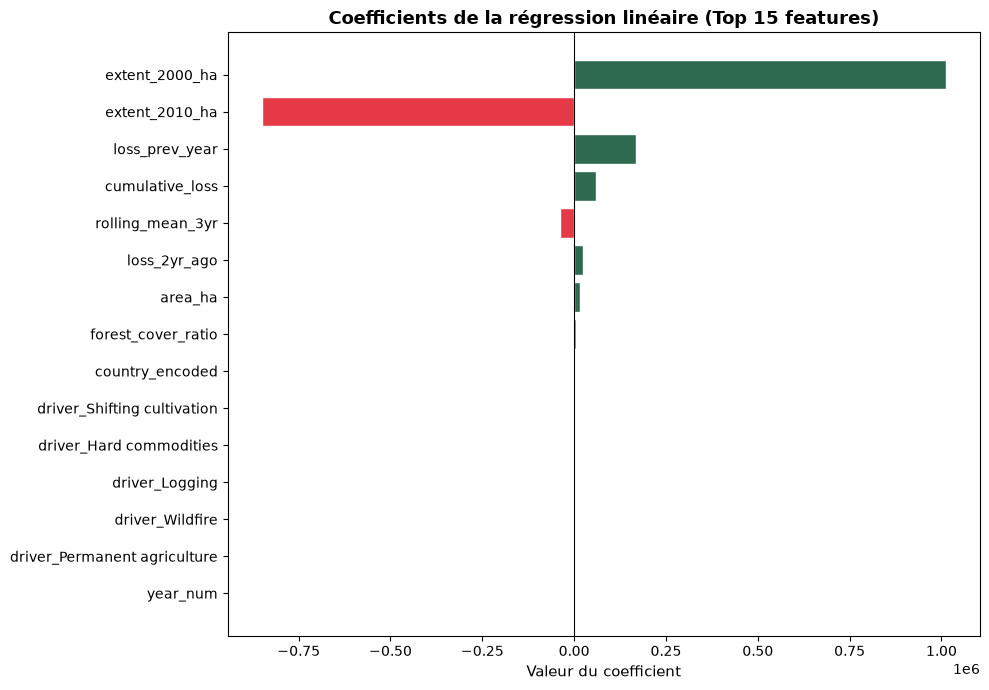

Figure sauvegardée


In [4]:
# Visualisation des coefficients (importance linéaire des features)
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': lr_model.coef_})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=True).index)
coef_df_top = coef_df.tail(15)  # Top 15 features

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e63946' if v < 0 else '#2d6a4f' for v in coef_df_top['coefficient']]
ax.barh(coef_df_top['feature'], coef_df_top['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coefficients de la régression linéaire (Top 15 features)', fontsize=13, fontweight='bold')
ax.set_xlabel('Valeur du coefficient', fontsize=11)
plt.tight_layout()
plt.savefig('figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

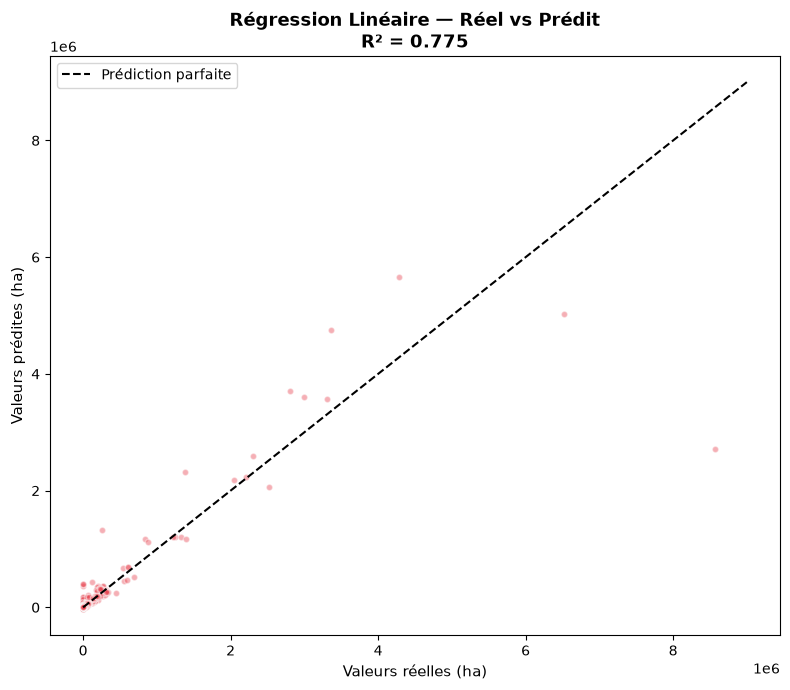

In [5]:
# Scatter plot : valeurs réelles vs prédites
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred, alpha=0.4, color='#e63946', edgecolors='white', s=20)
lim = max(y_test.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeurs réelles (ha)', fontsize=11)
ax.set_ylabel('Valeurs prédites (ha)', fontsize=11)
ax.set_title(f'Régression Linéaire — Réel vs Prédit\nR² = {r2:.3f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/lr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

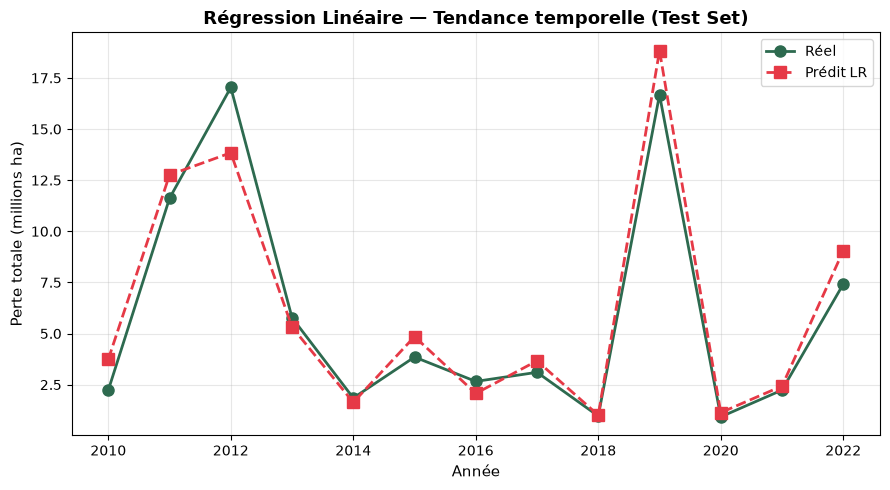

Toutes les figures sauvegardées dans figures/


In [6]:
# Courbe temporelle : agrégation par année sur le test set
import pandas as pd
n_years_test = 13  # Nombre d'années dans le test set (2010-2022)
n_per_year = len(y_test) // n_years_test

# Agrégation par somme sur les années de test
years_test = [2010 + i for i in range(n_years_test)]
real_sum  = [y_test[i*n_per_year:(i+1)*n_per_year].sum() for i in range(n_years_test)]
pred_sum  = [y_pred[i*n_per_year:(i+1)*n_per_year].sum() for i in range(n_years_test)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(years_test, np.array(real_sum)/1e6, 'o-', color='#2d6a4f', linewidth=2,
        markersize=8, label='Réel')
ax.plot(years_test, np.array(pred_sum)/1e6, 's--', color='#e63946', linewidth=2,
        markersize=8, label='Prédit LR')
ax.set_title('Régression Linéaire — Tendance temporelle (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Perte totale (millions ha)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/lr_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Toutes les figures sauvegardées dans figures/')